# <center>Make NIRSpec Simple Improved Reference Subtraction (SIRS) Calibration Files</center>

<center><center>Bernard J. Rauscher<br>
<em>Observational Cosmology Laboratory, NASA Goddard Space Flight Center, Greenbelt, MD, 21784, USA</em><br>
Bernard.J.Rauscher@nasa.gov</center></center>
<br>
<center>12 March 2025</center>

## Abstract

This notebook shows how to compute the Simple Improved Reference Subtraction (SIRS)$^1$ calibration files for JWST NIRSpec. SIRS provides statistically optimal reference correction if: (1) correlated read noise is strongly dominated by $1/f$ noise, (2) the reference pixel border is the only reference information that is available, and (3) the left and right reference columns are robustly averaged into 2048 two element vectors. Mathematically, SIRS is superior to smoothing the reference columns any other way (*i.e.* rolling median or Gauss smoothing). Although better than ad hoc reference correction, SIRS is inferior to NIRSpec's Improved Reference Sampling and Subtraction (IRS$^2$). We recomment that NIRSpec observers use IRS$^2$ when possible.$^2$

## 1 INTRODUCTION

We developed SIRS for Nancy Grace Roman Space Telescope (Roman) ground test data. At the time, Roman planned to follow NIRCam's example and downlink only co-averaged groups of data. When Roman testing in the Goddard Detector Characterization Laboratory (DCL) revealed undesirably high $1/f$ noise, we developed SIRS as a mitigation that was consistent with NIRCam-like plans. SIRS is therefore directly applicable to JWST's near-infrared detectors as well.

Fortunately, the SIRS study convinced the Roman Project to downlink the reference output. Roman will not use SIRS on orbit. Instead, it will use Improved Roman Reference Correction (IRRC).

## 2 PREPROCESSING

In the JWST Pipeline, SIRS takes the place of reference correction using side reference pixels. For training, you should apply all pipeline steps up through reference correction. For the reference correction step: (1) do not apply the alternating columns noise correction and (2) do not apply the reference columns correction. This overrides the defaults.

## 3 TUTORIAL

### 3.1 Preliminaries

This document is an executable Jupyter notebook. This is Julia.

In [1]:
# Standard packages
using Revise, Glob, FITSIO, HDF5, Plots, FFTW, LaTeXStrings, Measures

# Load SIRS
using SIRS

# Definitions. I am working on the National Center for Climate Simulation (NCCS)
# high performance Prism cluster.
prog_id = "06633"                         # The input data are from this Program ID. 
                                          # They are required to be long darks.
outdir = "/explore/nobackup/people/brausche"*
                "/data/JWST/Library/SIRS" # Write results here
datdir = "/lscratch/brausche"             # Stage data to Prism's high speed disks
nint = 1                                  # Number of integrations per exposure
nframe = 88                               # This many frames per integration
nz = 44                                   # Work in "chunks" of this many frames to fit in GPU RAM

# Vectors of all SWIR NIRCam sensor chip systems (SCS)
nrs = ["nrs1", "nrs2"]

# The flight data have many cosmic rays. Instantiate the
# cosmic ray fixer.
F = CRFix(nframe);

### 3.2 Compute NRCA Calibration File

Compute frequencies and frequency dependent weights for NRCA.

In [2]:
f = []
γ = []
ζ = []
ps_𝓵 = []
ps_𝓻 = []
ps_𝓷 = []
for scs in nrs
       
    # Display status
    println("Processing SCS ", scs)

    # Get input files
    files = glob("*"*scs*"*.fits", datdir)
    
    # Do it
    f, _γ, _ζ, _ps_𝓵, _ps_𝓻, _ps_𝓷 = nircam_sirs_solve(F, nz, files)
    push!(γ, _γ)
    push!(ζ, _ζ)  
    push!(ps_𝓵, _ps_𝓵)
    push!(ps_𝓻, _ps_𝓻)
    push!(ps_𝓷, _ps_𝓷)
    
end

Processing SCS nrs1
processing jw06633085001_02201_00001_nrs1_refpixstep.fits integration 1
processing jw06633086001_05201_00001_nrs1_refpixstep.fits integration 1
processing jw06633087001_02201_00001_nrs1_refpixstep.fits integration 1
processing jw06633088001_04201_00001_nrs1_refpixstep.fits integration 1
processing jw06633089001_04201_00001_nrs1_refpixstep.fits integration 1
processing jw06633090001_02201_00001_nrs1_refpixstep.fits integration 1
processing jw06633091001_02201_00001_nrs1_refpixstep.fits integration 1
processing jw06633093001_02301_00001_nrs1_refpixstep.fits integration 1
processing jw06633094001_02201_00001_nrs1_refpixstep.fits integration 1
processing jw06633097001_06201_00001_nrs1_refpixstep.fits integration 1
processing jw06633098001_07201_00001_nrs1_refpixstep.fits integration 1
processing jw06633099001_09201_00001_nrs1_refpixstep.fits integration 1
processing jw06633100001_04201_00001_nrs1_refpixstep.fits integration 1
processing jw06633101001_06201_00001_nrs1_re

In [3]:
# Save
SIRS.h5write(prog_id, Float32.(f), γ, ζ, ps_𝓵, ps_𝓻, ps_𝓷,
            nrs, outdir*"/20250312_sirs_nirspec.h5")

## Acknowledgments

This work was supported by the James Webb Space Telescope and Nancy Grace Roman Space Telescope Projects. Resources supporting this work were provided by the NASA High-End Computing (HEC) Program through the NASA Center for Climate Simulation (NCCS) at Goddard Space Flight Center.

## Bibliography
1. Rauscher, B. J., Fixsen, D. J. & Mosby, G. *Simple improved reference subtraction for H4RG, H2RG, and H1RG near-infrared array detectors.* JATIS, Syst. 8, 28002 (2022).
2. Rauscher, B. J. *et al. Improved Reference Sampling and Subtraction: A Technique for Reducing the Read Noise of Near-infrared Detector Systems.* PASP 129, 105003 (2017).

## Appendix. Validate Results

Make some plots to show that things are working as expected.

In [22]:
(f, γ, ζ) = h5open(outdir*"/20250312_sirs_nirspec.h5") do fid
    f = read_attribute(fid, "rfftfreq")
    γ = [read_dataset(fid, "nrs1/gamma"), read_dataset(fid, "nrs2/gamma")]
    ζ = [read_dataset(fid, "nrs1/zeta"), read_dataset(fid, "nrs2/zeta")]
    (f, γ, ζ)
end;

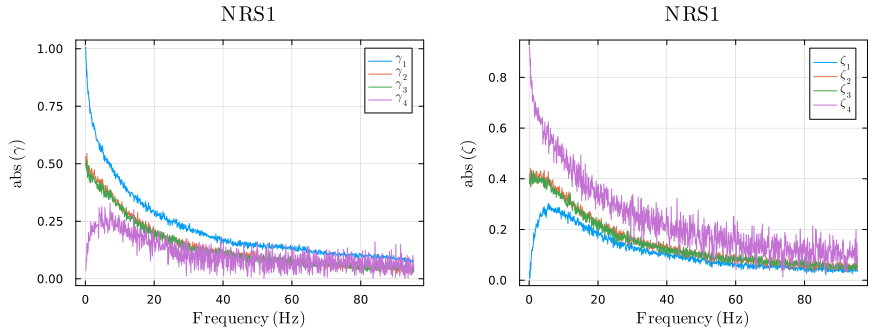

In [25]:
# NRS1
panel_a = plot(f[2:end], abs.(γ[1][2:end,:]), framestyle=:box, label=[L"\gamma_1" L"\gamma_2" L"\gamma_3" L"\gamma_4"],
    xlab=L"\mathrm{Frequency~(Hz)}", ylab=L"\mathrm{abs}~(\gamma)", title=L"\mathrm{NRS1}")
panel_b = plot(f[2:end], abs.(ζ[1][2:end,:]), framestyle=:box, label=[L"\zeta_1" L"\zeta_2" L"\zeta_3" L"\zeta_4"],
    xlab=L"\mathrm{Frequency~(Hz)}", ylab=L"\mathrm{abs}~(\zeta)", title=L"\mathrm{NRS1}")
plt = plot(panel_a, panel_b, layout=(1,2), size=(.7*2*640,.7*480), margin=5mm)
savefig(plt, "/home/brausche/tmp/nrs1_plot.pdf")
plt

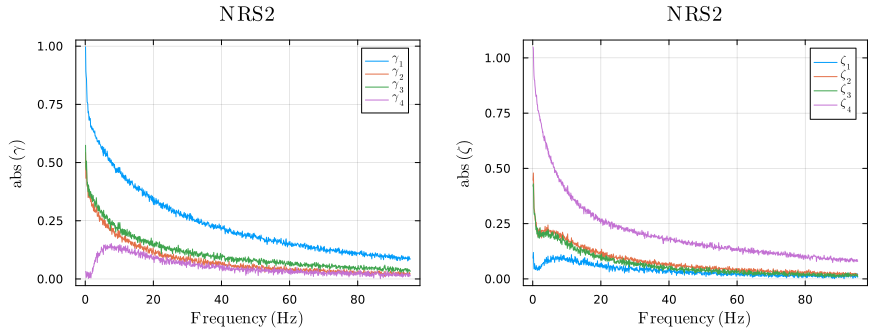

In [26]:
# NRS2
panel_a = plot(f[2:end], abs.(γ[2][2:end,:]), framestyle=:box, label=[L"\gamma_1" L"\gamma_2" L"\gamma_3" L"\gamma_4"],
    xlab=L"\mathrm{Frequency~(Hz)}", ylab=L"\mathrm{abs}~(\gamma)", title=L"\mathrm{NRS2}")
panel_b = plot(f[2:end], abs.(ζ[2][2:end,:]), framestyle=:box, label=[L"\zeta_1" L"\zeta_2" L"\zeta_3" L"\zeta_4"],
    xlab=L"\mathrm{Frequency~(Hz)}", ylab=L"\mathrm{abs}~(\zeta)", title=L"\mathrm{NRS2}")
plt = plot(panel_a, panel_b, layout=(1,2), size=(.7*2*640,.7*480), margin=5mm)
savefig(plt, "/home/brausche/tmp/nrs2_plot.pdf")
plt